# 11 — Image Condition Ablation

Compares model behaviour when the real image is replaced with a degraded image:
- **blank** — standard blind condition (224×224 blank PNG)
- **gray** — uniform gray image
- **noise** — random pixel noise
- **white** — uniform white image (4B only)

**Primary example:** Qwen3-VL-4B (all four conditions, 8B included for comparison)

Key findings:
- Qwen3-VL-**4B** outputs are **identical** across all four conditions — the model completely ignores image content.
- Qwen3-VL-**8B** shows clear degradation: blank > gray > noise in accuracy, with ~38–51% of answers changing.

In [12]:
import sys
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import sem as scipy_sem

BASE = Path('..').resolve().parent   # repo root
sys.path.insert(0, str(BASE))
sys.path.insert(0, str(BASE / 'analysis'))

from utils.vqa import preprocess_answer, VQAAnswerMapper, vqa_accuracy

LOGITS   = BASE / 'evaluation/logits'
OUT_DIR  = BASE / 'latex/AnonymousSubmission/LaTeX/figures/ablation_image'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
})

COND_COLORS = {
    'blank': '#455A64',
    'gray':  '#78909C',
    'noise': '#E53935',
    'white': '#FB8C00',
}
COND_LABEL = {'blank': 'Blank', 'gray': 'Gray', 'noise': 'Noise', 'white': 'White'}

In [13]:
# ── File registry ──────────────────────────────────────────────────────────────
MODELS = {
    'Qwen3-VL-4B': {
        'answer_key': 'question',
        'conditions': {
            'blank': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind.jsonl',
            'gray':  LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_gray.jsonl',
            'noise': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_noise.jsonl',
            'white': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_white.jsonl',
        },
    },
    'Qwen3-VL-8B': {
        'answer_key': 'question',
        'conditions': {
            'blank': LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind.jsonl',
            'gray':  LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind_gray.jsonl',
            'noise': LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind_noise.jsonl',
        },
    },
}

SOFT_ABSTAIN = {'nothing', 'none', 'nowhere', 'unanswerable', 'unknown',
                'no answer', 'no image', 'no picture', "i don't know",
                "i'm sorry", 'i cannot', 'i can not', 'i am unable',
                'i am not able', 'unable to'}

def is_soft_abstain(ans: str) -> bool:
    a = ans.lower().strip()
    return any(a.startswith(tok) for tok in SOFT_ABSTAIN)


def load_condition(path: Path, answer_key: str, mapper: VQAAnswerMapper) -> pd.DataFrame:
    rows = []
    with open(path) as fh:
        for line in fh:
            ex  = json.loads(line.strip())
            qid = int(ex['question_id'])
            raw = ex.get('generated_answers', {}).get(answer_key, '')
            ans = preprocess_answer(str(raw), strip_think=True)
            gt  = mapper.get_answers(qid)
            acc = vqa_accuracy(ans, gt) if gt else float('nan')
            rows.append({
                'qid':        qid,
                'answer':     ans,
                'raw':        str(raw),
                'acc':        acc,
                'atype':      ex.get('answer_type', 'other'),
                'is_abstain': is_soft_abstain(ans),
                'is_loop':    '<|im_start|>' in str(raw),
            })
    return pd.DataFrame(rows)


def save(fig, name):
    path = OUT_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {name}')

In [14]:
# ── Load all data ──────────────────────────────────────────────────────────────
print('Loading VQA annotations…')
mapper = VQAAnswerMapper()

data: dict[str, dict[str, pd.DataFrame]] = {}
for model, cfg in MODELS.items():
    print(f'\nLoading {model}…')
    data[model] = {}
    for cond, path in cfg['conditions'].items():
        df = load_condition(path, cfg['answer_key'], mapper)
        data[model][cond] = df
        print(f'  {cond}: n={len(df)}  mean_acc={df["acc"].mean():.4f}  '
              f'abstain={df["is_abstain"].mean():.3f}  loop={df["is_loop"].mean():.3f}')

Loading VQA annotations…

Loading Qwen3-VL-4B…
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  blank: n=1000  mean_acc=0.0010  abstain=0.634  loop=0.017
  gray: n=1000  mean_acc=0.0010  abstain=0.634  loop=0.017
  noise: n=1000  mean_acc=0.0010  abstain=0.634  loop=0.017
  white: n=1000  mean_acc=0.0010  abstain=0.634  loop=0.017

Loading Qwen3-VL-8B…
  blank: n=1000  mean_acc=0.3417  abstain=0.084  loop=0.000
  gray: n=1000  mean_acc=0.3097  abstain=0.168  loop=0.000
  noise: n=1000  mean_acc=0.2617  abstain=0.332  loop=0.000


## Summary table

In [15]:
ALL_CONDS = ['blank', 'gray', 'noise', 'white']

rows = []
for model in MODELS:
    blank_ans = data[model]['blank'].set_index('qid')['answer']
    for cond in ALL_CONDS:
        if cond not in data[model]:
            continue
        df    = data[model][cond]
        other = df.set_index('qid')['answer']
        common  = blank_ans.index.intersection(other.index)
        changed = float('nan') if cond == 'blank' else (blank_ans[common] != other[common]).mean()
        rows.append({
            'Model':               model,
            'Condition':           COND_LABEL[cond],
            'Mean acc':            round(df['acc'].mean(), 4),
            'Abstain %':           round(df['is_abstain'].mean() * 100, 1),
            'Loop %':              round(df['is_loop'].mean() * 100, 1),
            'Changed vs blank %':  '' if cond == 'blank' else f'{changed*100:.1f}',
        })

pd.DataFrame(rows)

,Model,Condition,Mean acc,Abstain %,Loop %,Changed vs blank %
0,Qwen3-VL-4B,Blank,0.0010,63.4,1.7,
1,Qwen3-VL-4B,Gray,0.0010,63.4,1.7,0.0
2,Qwen3-VL-4B,Noise,0.0010,63.4,1.7,0.0
3,Qwen3-VL-4B,White,0.0010,63.4,1.7,0.0
4,Qwen3-VL-8B,Blank,0.3417,8.4,0.0,
5,Qwen3-VL-8B,Gray,0.3097,16.8,0.0,38.1
6,Qwen3-VL-8B,Noise,0.2617,33.2,0.0,51.0


## Fig 1 — Accuracy by image condition

Saved: accuracy_by_condition.png


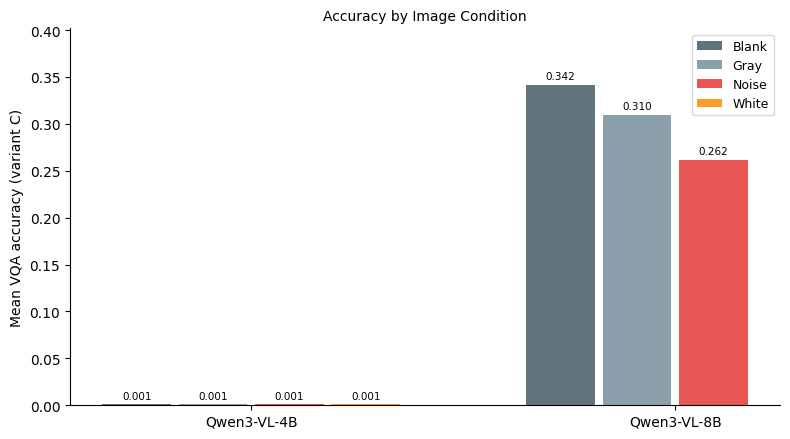

In [16]:
models_plot = list(MODELS.keys())
n_models = len(models_plot)
n_conds  = len(ALL_CONDS)
x = np.arange(n_models)
w = 0.18

fig, ax = plt.subplots(figsize=(8, 4.5))
for ci, cond in enumerate(ALL_CONDS):
    accs = []
    for model in models_plot:
        df = data[model].get(cond)
        accs.append(df['acc'].mean() if df is not None else float('nan'))
    offset = (ci - (n_conds - 1) / 2) * w
    bars = ax.bar(x + offset, accs, w * 0.9,
                  color=COND_COLORS[cond], label=COND_LABEL[cond], alpha=0.85)
    for bar, val in zip(bars, accs):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(models_plot, fontsize=10)
ax.set_ylabel('Mean VQA accuracy (variant C)', fontsize=10)
ax.set_title('Accuracy by Image Condition', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
save(fig, 'accuracy_by_condition.png')
plt.show()

## Fig 2 — Answer change rate vs blank baseline

Saved: answer_change_rate.png


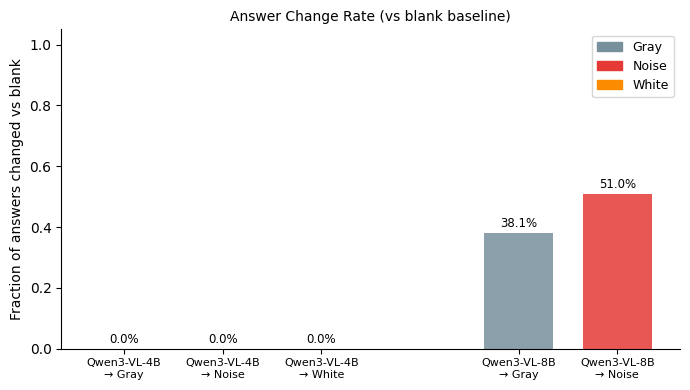

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
tick_pos, tick_labels = [], []
bar_idx = 0

for mi, model in enumerate(models_plot):
    blank_ans       = data[model]['blank'].set_index('qid')['answer']
    conds_nonblank  = [c for c in ALL_CONDS if c != 'blank' and c in data[model]]
    for j, cond in enumerate(conds_nonblank):
        other   = data[model][cond].set_index('qid')['answer']
        common  = blank_ans.index.intersection(other.index)
        changed = (blank_ans[common] != other[common]).mean()
        bar = ax.bar(bar_idx, changed, color=COND_COLORS[cond], alpha=0.85, width=0.7)
        ax.text(bar_idx, changed + 0.01, f'{changed*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5)
        tick_pos.append(bar_idx)
        tick_labels.append(f'{model}\n→ {COND_LABEL[cond]}')
        bar_idx += 1
    bar_idx += 1   # gap between models

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel('Fraction of answers changed vs blank', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title('Answer Change Rate (vs blank baseline)', fontsize=10)
legend_patches = [mpatches.Patch(color=COND_COLORS[c], label=COND_LABEL[c])
                  for c in ALL_CONDS if c != 'blank']
ax.legend(handles=legend_patches, fontsize=9, frameon=True, loc='upper right')
plt.tight_layout()
save(fig, 'answer_change_rate.png')
plt.show()

## Fig 3 — Qwen3-VL-4B: image condition has no effect

All outputs from the 4B model are **identical** to the blank baseline regardless of the image shown.

Saved: qwen3vl4b_image_invariance.png


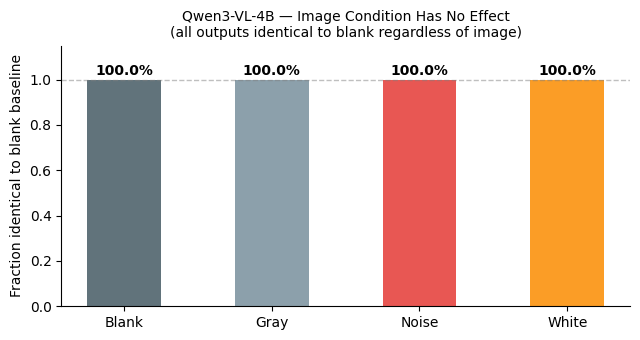

In [18]:
model    = 'Qwen3-VL-4B'
conds_4b = [c for c in ALL_CONDS if c in data[model]]
blank_ans = data[model]['blank'].set_index('qid')['answer']

fig, ax = plt.subplots(figsize=(6.5, 3.5))
same_rates = []
for cond in conds_4b:
    if cond == 'blank':
        same_rates.append(1.0)
        continue
    other  = data[model][cond].set_index('qid')['answer']
    common = blank_ans.index.intersection(other.index)
    same_rates.append((blank_ans[common] == other[common]).mean())

colors = [COND_COLORS[c] for c in conds_4b]
bars   = ax.bar(range(len(conds_4b)), same_rates, color=colors, alpha=0.85, width=0.5)
for bar, val, cond in zip(bars, same_rates, conds_4b):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(conds_4b)))
ax.set_xticklabels([COND_LABEL[c] for c in conds_4b], fontsize=10)
ax.set_ylabel('Fraction identical to blank baseline', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Qwen3-VL-4B — Image Condition Has No Effect\n'
             '(all outputs identical to blank regardless of image)', fontsize=10)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
save(fig, 'qwen3vl4b_image_invariance.png')
plt.show()

## Fig 4 — Qwen3-VL-8B: accuracy by question type and image condition

Saved: qwen3vl8b_accuracy_by_qtype.png


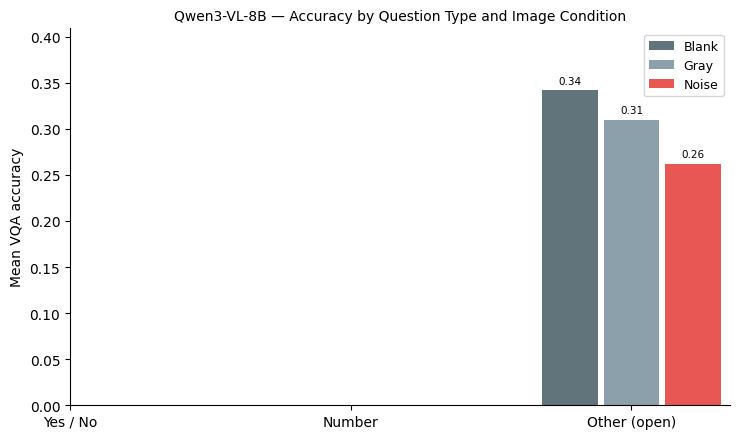

In [19]:
model  = 'Qwen3-VL-8B'
atypes = ['yes/no', 'number', 'other']
conds  = [c for c in ALL_CONDS if c in data[model]]

atype_accs = {cond: {} for cond in conds}
for cond in conds:
    df = data[model][cond]
    for at in atypes:
        sub = df[df['atype'] == at]
        atype_accs[cond][at] = sub['acc'].mean() if len(sub) else float('nan')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
n_at = len(atypes)
x    = np.arange(n_at)
w    = 0.22
for ci, cond in enumerate(conds):
    vals   = [atype_accs[cond].get(at, float('nan')) for at in atypes]
    offset = (ci - (len(conds) - 1) / 2) * w
    bars   = ax.bar(x + offset, vals, w * 0.9,
                    color=COND_COLORS[cond], label=COND_LABEL[cond], alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(['Yes / No', 'Number', 'Other (open)'], fontsize=10)
ax.set_ylabel('Mean VQA accuracy', fontsize=10)
ax.set_title('Qwen3-VL-8B — Accuracy by Question Type and Image Condition', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(0, ax.get_ylim()[1] * 1.14)
plt.tight_layout()
save(fig, 'qwen3vl8b_accuracy_by_qtype.png')
plt.show()

## Human–Model agreement vs image condition (variant C only)\n\nThe ablation was run on variant C only (`question` key). For each image condition, compute mean HM agreement across all human answers.\nMetrics: exact, Jaccard, chrF, SBERT cosine.

In [20]:
from utils.agreement import _pair_exact, _pair_jaccard, _pair_chrf, encode_with_cache
from sentence_transformers import SentenceTransformer

EXPORTS_DIR = BASE / 'analysis/session2/exports'
SBERT_CACHE = EXPORTS_DIR / 'embeddings_all-mpnet-base-v2.npz'

# Only variant C was run in the ablation
print('Loading human responses (variant C)…')
human_df  = pd.read_csv(EXPORTS_DIR / 'responses_human.csv')
human_df  = human_df[human_df['variant'] == 'C'].copy()

# Restrict to questions present in the ablation data
ablation_qids = set(data['Qwen3-VL-4B']['blank']['qid'].unique())
human_df = human_df[human_df['question_id'].isin(ablation_qids)].copy()
n_q, n_h = human_df['question_id'].nunique(), human_df['participant'].nunique()
HM_SUFFIX = f'_q{n_q}_h{n_h}'
print(f'  {n_q} questions × {n_h} participants')

print('\nLoading SBERT model…')
sbert_model = SentenceTransformer('all-mpnet-base-v2')

all_answers: set[str] = set()
for row in human_df['response'].dropna():
    all_answers.add(preprocess_answer(str(row)))
for model_name in MODELS:
    for cond_df in data[model_name].values():
        all_answers.update(cond_df['answer'])

print(f'Encoding {len(all_answers)} unique answers…')
ans2emb = encode_with_cache(list(all_answers), sbert_model, SBERT_CACHE, verbose=True)


def cosine(a: str, b: str) -> float:
    v1, v2 = ans2emb.get(a), ans2emb.get(b)
    return float(np.dot(v1, v2)) if (v1 is not None and v2 is not None) else float('nan')


def hm_agreement_for_condition(model_name: str, cond: str) -> pd.DataFrame:
    """Per-question HM agreement for variant C across all human answers."""
    model_answers = data[model_name][cond].set_index('qid')['answer']
    rows = []
    for qid, m_ans in model_answers.items():
        h_answers = [preprocess_answer(str(a))
                     for a in human_df[human_df['question_id'] == qid]['response'].dropna()]
        for h_ans in h_answers:
            rows.append({
                'qid':       qid,
                'model_ans': m_ans,
                'human_ans': h_ans,
                'exact':     _pair_exact(m_ans, h_ans),
                'jaccard':   _pair_jaccard(m_ans, h_ans),
                'chrf':      _pair_chrf(m_ans, h_ans),
                'sbert':     cosine(m_ans, h_ans),
            })
    return pd.DataFrame(rows)

Loading human responses (variant C)…
  113 questions × 40 participants

Loading SBERT model…
Encoding 2338 unique answers…
All 2338 answers found in cache (embeddings_all-mpnet-base-v2.npz)


Qwen3-VL-4B / exact…
Qwen3-VL-8B / exact…
Saved: hm_agreement_exact_by_condition_q113_h40.png


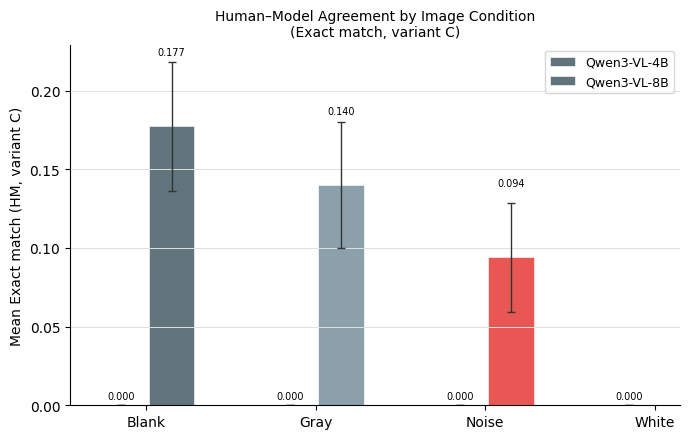

Qwen3-VL-4B / jaccard…
Qwen3-VL-8B / jaccard…
Saved: hm_agreement_jaccard_by_condition_q113_h40.png


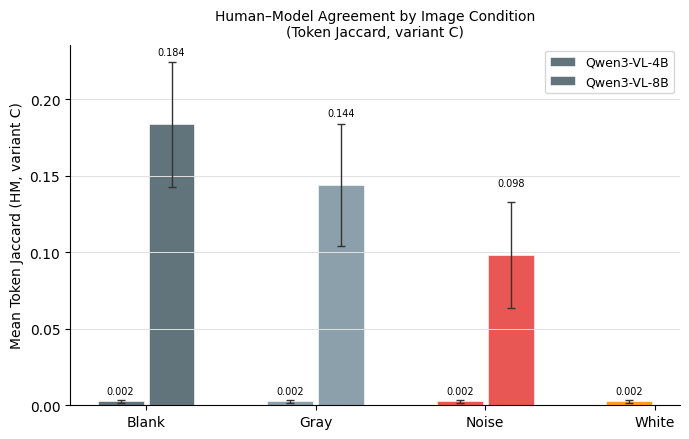

Qwen3-VL-4B / chrf…
Qwen3-VL-8B / chrf…
Saved: hm_agreement_chrf_by_condition_q113_h40.png


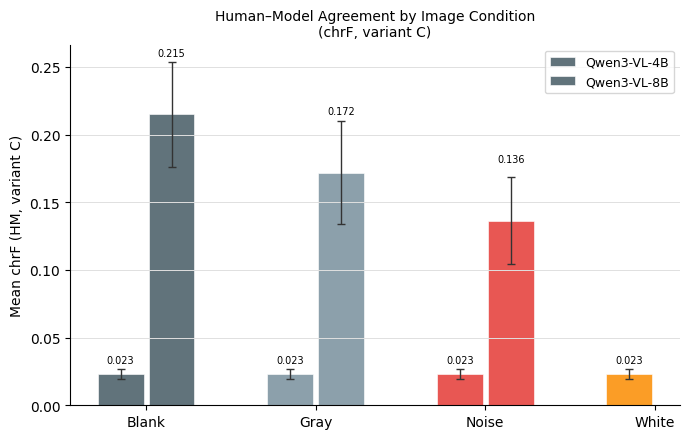

Qwen3-VL-4B / sbert…
Qwen3-VL-8B / sbert…
Saved: hm_agreement_sbert_by_condition_q113_h40.png


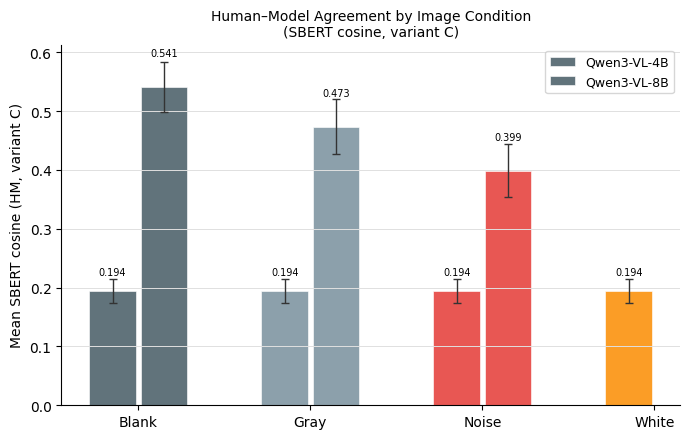

In [21]:
HM_AGMT_METRICS = [
    ('exact',   'Exact match'),
    ('jaccard', 'Token Jaccard'),
    ('chrf',    'chrF'),
    ('sbert',   'SBERT cosine'),
]

# One grouped bar chart per metric: x = image condition, groups = models
for metric_key, metric_name in HM_AGMT_METRICS:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    models_avail = list(MODELS.keys())
    n_m = len(models_avail)
    w   = 0.3

    for mi, model_name in enumerate(models_avail):
        conds_avail = list(MODELS[model_name]['conditions'].keys())
        print(f'{model_name} / {metric_key}…')

        xs, ys, cis_vals, bar_colors = [], [], [], []
        for ci, cond in enumerate(conds_avail):
            df_pairs = hm_agreement_for_condition(model_name, cond)
            q_means  = df_pairs.groupby('qid')[metric_key].mean()
            ys.append(q_means.mean())
            cis_vals.append(1.96 * float(scipy_sem(q_means.dropna())))
            xs.append(ci)
            bar_colors.append(COND_COLORS[cond])

        offset = (mi - (n_m - 1) / 2) * w
        bars = ax.bar([x + offset for x in xs], ys, w * 0.9,
                      color=bar_colors, alpha=0.85,
                      label=model_name, edgecolor='white', linewidth=0.5)
        ax.errorbar([x + offset for x in xs], ys, yerr=cis_vals,
                    fmt='none', color='#333333', capsize=3, lw=1.0)
        for bar, val in zip(bars, ys):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(cis_vals) + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    all_conds_ordered = ['blank', 'gray', 'noise', 'white']
    # x-axis ticks: use blank/gray/noise (common), white only for 4B — label all positions
    cond_ticks = sorted(set(
        c for m in MODELS for c in MODELS[m]['conditions']
    ), key=all_conds_ordered.index)
    ax.set_xticks(range(len(cond_ticks)))
    ax.set_xticklabels([COND_LABEL[c] for c in cond_ticks], fontsize=10)
    ax.set_ylabel(f'Mean {metric_name} (HM, variant C)', fontsize=10)
    ax.set_title(f'Human–Model Agreement by Image Condition\n({metric_name}, variant C)', fontsize=10)
    ax.legend(fontsize=9, frameon=True, loc='upper right')
    ax.grid(axis='y', color='#E0E0E0', lw=0.7)
    plt.tight_layout()
    fname = f'hm_agreement_{metric_key}_by_condition{HM_SUFFIX}.png'
    save(fig, fname)
    plt.show()